In [1]:
print("Hello, Lane Detection!")

Hello, Lane Detection!


In [3]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os

print(os.listdir("/content/drive/MyDrive"))

['4C Fina Nuril Aulia Diagram Use Case Aplikasi Mango Mart .pdf', 'KTI FINA NURIL AULIA XII MIA 2.pdf', 'PROJECT FINA NURIL AULIA XII MIA 2.rar', '16367070688902875633956921042807.jpg', '16367071051928434766442480751585.jpg', 'Kelengkapan span ptkin', 'Screenshot_20220807-080651_Gallery (1).jpg', 'Screenshot_20220807-080948_Gallery.jpg', 'Screenshot_20220807-080651_Gallery.jpg', 'Screenshot_20220808-164051_Chrome.jpg', 'MATERI 1 FINA NURIL AULIA KELOMPOK 11 T.MTK.pdf', 'MATERI 2 FINA NURIL AULIA KELOMPOK 11 T MTK.pdf', 'MATERI 3 FINA NURIL AULIA.pdf', 'MATERI 4 FINA.pdf', 'MATERI 5 FINA NURIL AULIA.pdf', 'Fina', 'Daftar uyp', 'Classroom', 'TUGAS SISFO WHATSAPP.drawio', 'DFD WHATSAPP KELOMPOK 4.pdf', 'nilai 1.gsheet', 'Students Social Media Addiction.gsheet', 'LAPORAN PROYEK AKHIR FINA NURIL AULIA (2).docx', 'LAPORAN PROYEK AKHIR FINA NURIL AULIA (1).gdoc', 'LAPORAN PROYEK AKHIR FINA NURIL AULIA.gdoc', 'Formulir tanpa judul.gform', 'Respon Proyek Sistem Manajemen Sederhana untuk UMKM.gs

In [5]:
print(os.listdir("/content/drive/MyDrive/road-detection1"))

['video_jalan.mp4', 'jalan.jpeg', 'output', 'hasil_lane_temp.avi']


In [6]:
import cv2

IMAGE_PATH = "/content/drive/MyDrive/road-detection1/jalan.jpeg"

image = cv2.imread(IMAGE_PATH)

if image is None:
    print("❌ Gambar tidak dapat dibuka")
else:
    print("✅ Gambar berhasil dibuka")
    print("Ukuran gambar:", image.shape)

✅ Gambar berhasil dibuka
Ukuran gambar: (928, 1600, 3)


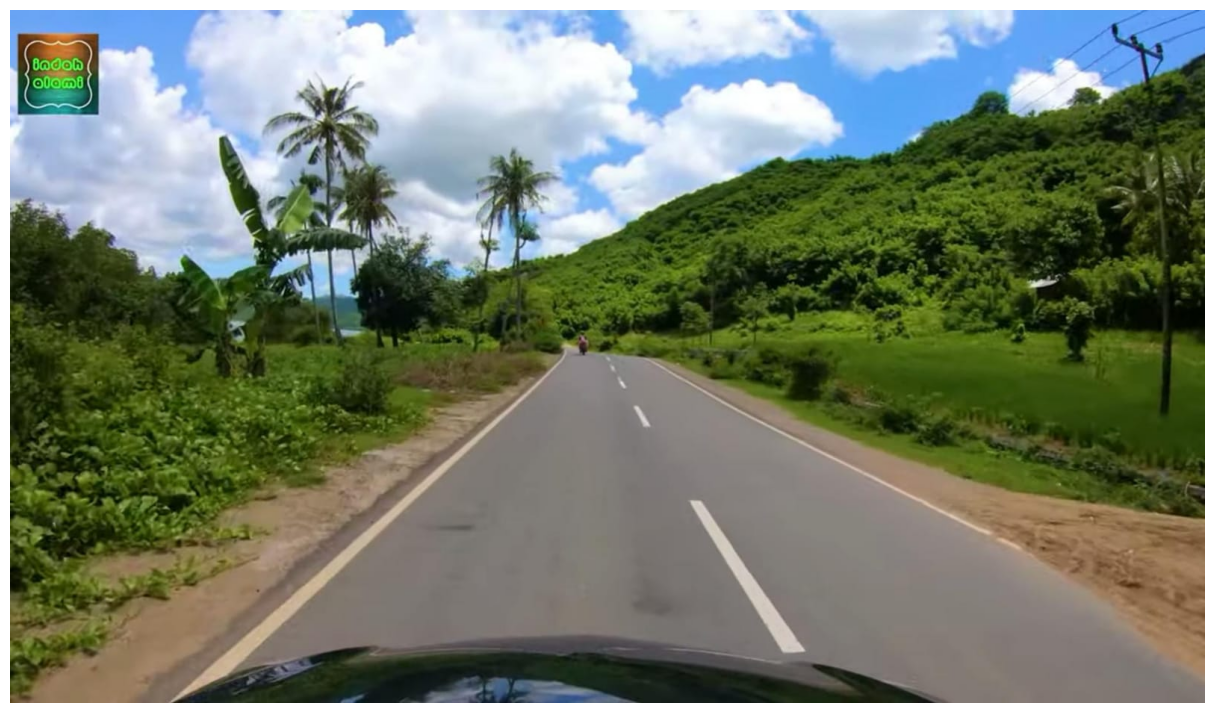

In [7]:
import matplotlib.pyplot as plt

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(16, 9))
plt.imshow(image_rgb)
plt.axis("off")
plt.show()

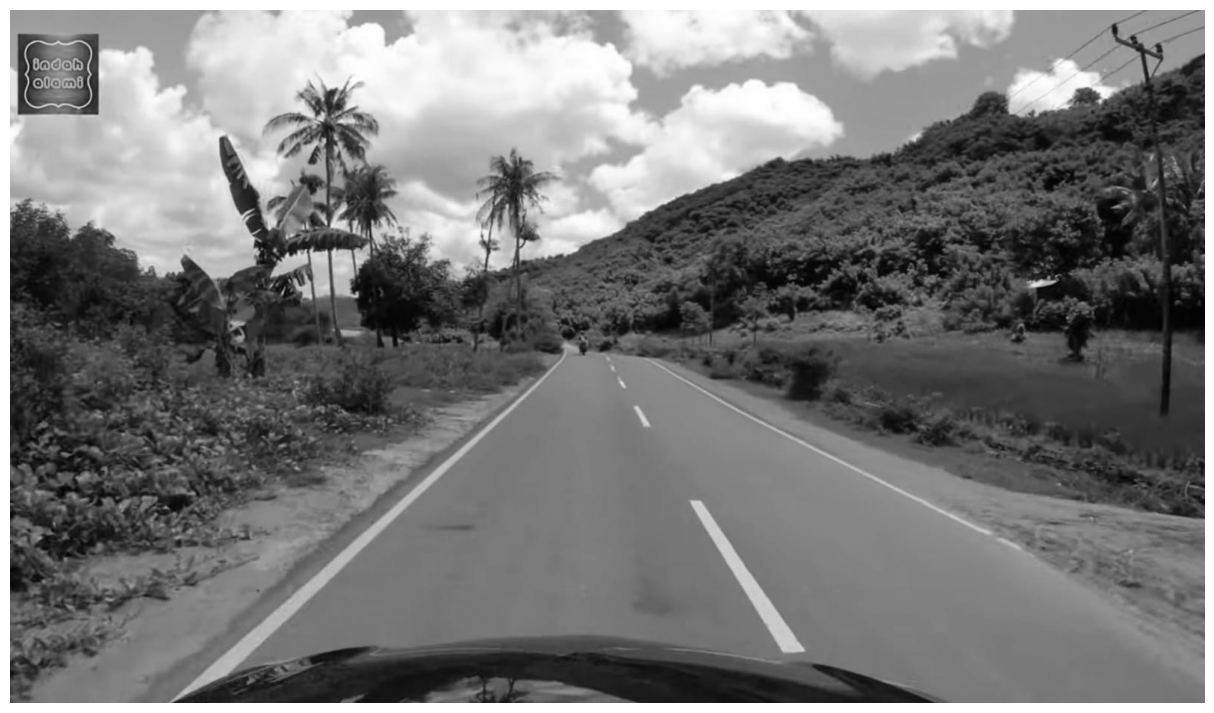

In [8]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(16, 9))
plt.imshow(gray, cmap="gray")
plt.axis("off")
plt.show()

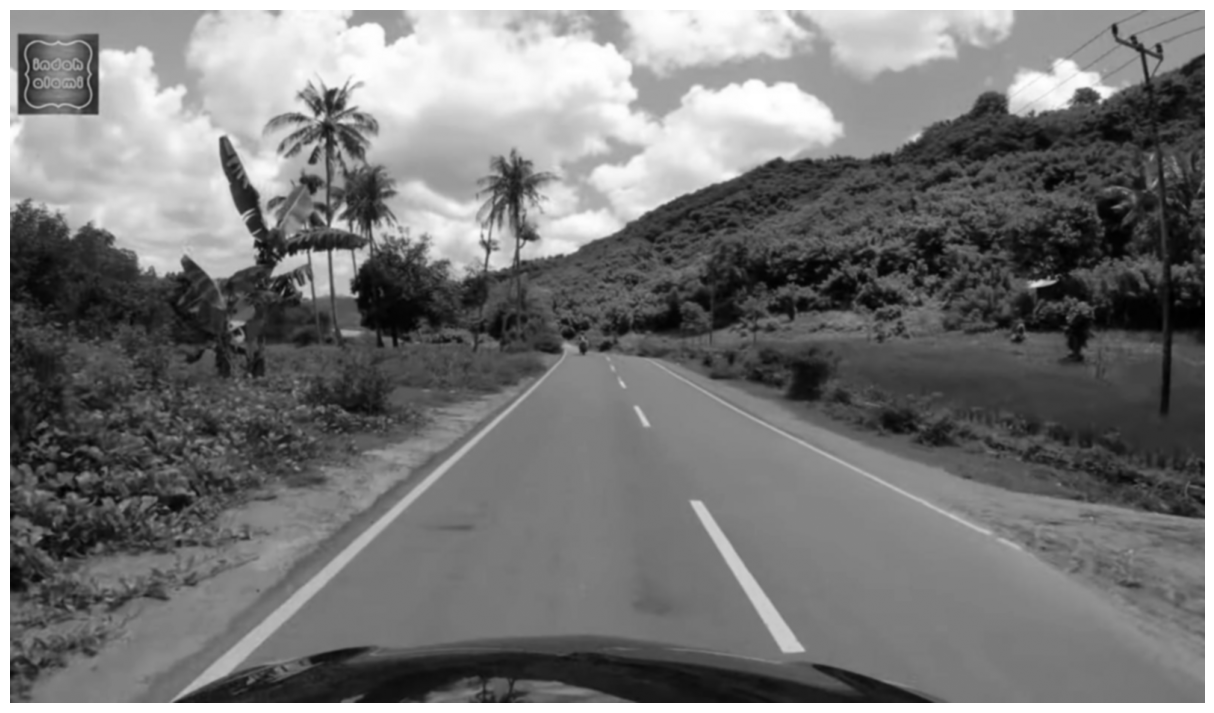

In [9]:
blur = cv2.GaussianBlur(
    gray,
    (5, 5),
    0
)

plt.figure(figsize=(16, 9))
plt.imshow(blur, cmap="gray")
plt.axis("off")
plt.show()

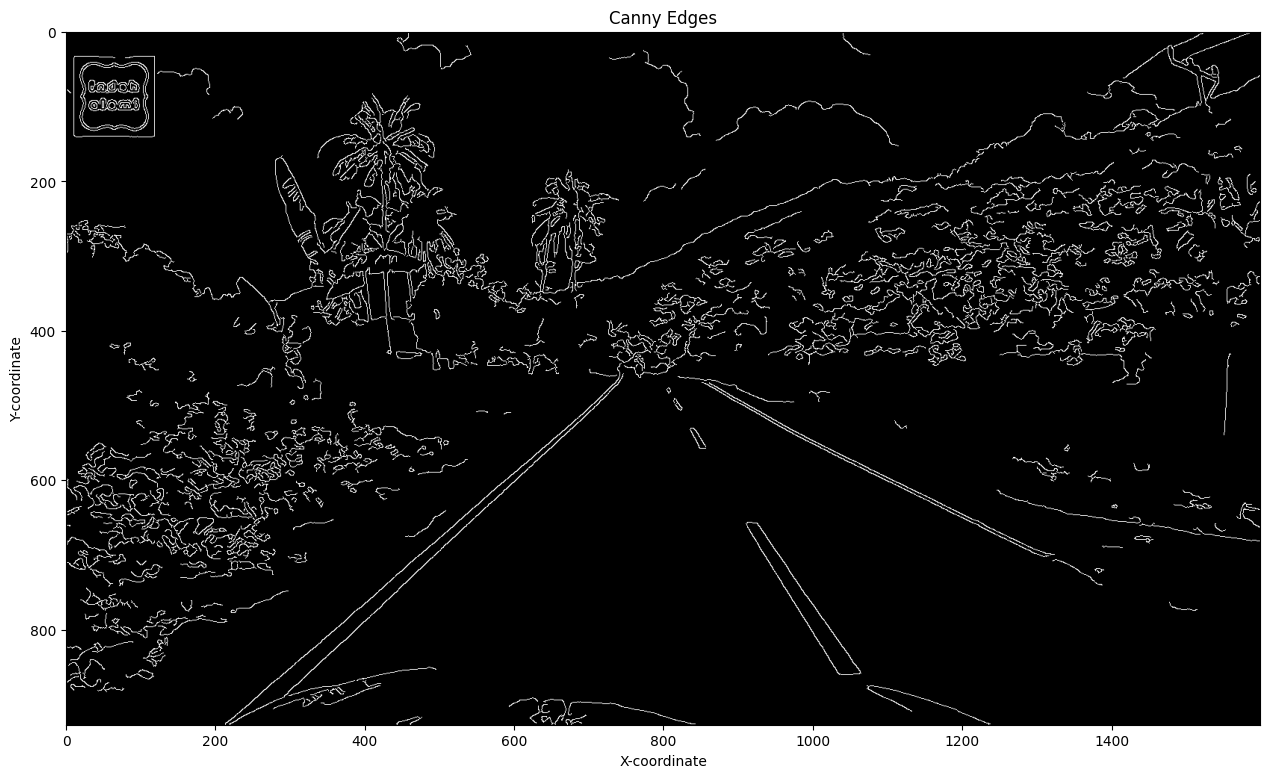

In [20]:
edges = cv2.Canny(
    blur,
    50,
    150
)

plt.figure(figsize=(16, 9))
plt.imshow(edges, cmap="gray")
plt.title("Canny Edges")
plt.xlabel("X-coordinate")
plt.ylabel("Y-coordinate")
plt.axis("on") # Tampilkan sumbu X dan Y
plt.show()

In [12]:
lines = cv2.HoughLinesP(
    roi,
    rho=1,
    theta=np.pi / 180,
    threshold=50,
    minLineLength=80,
    maxLineGap=120
)

if lines is None:
    print("❌ Tidak ada garis yang terdeteksi")
else:
    print("✅ Jumlah garis terdeteksi:", len(lines))

✅ Jumlah garis terdeteksi: 10


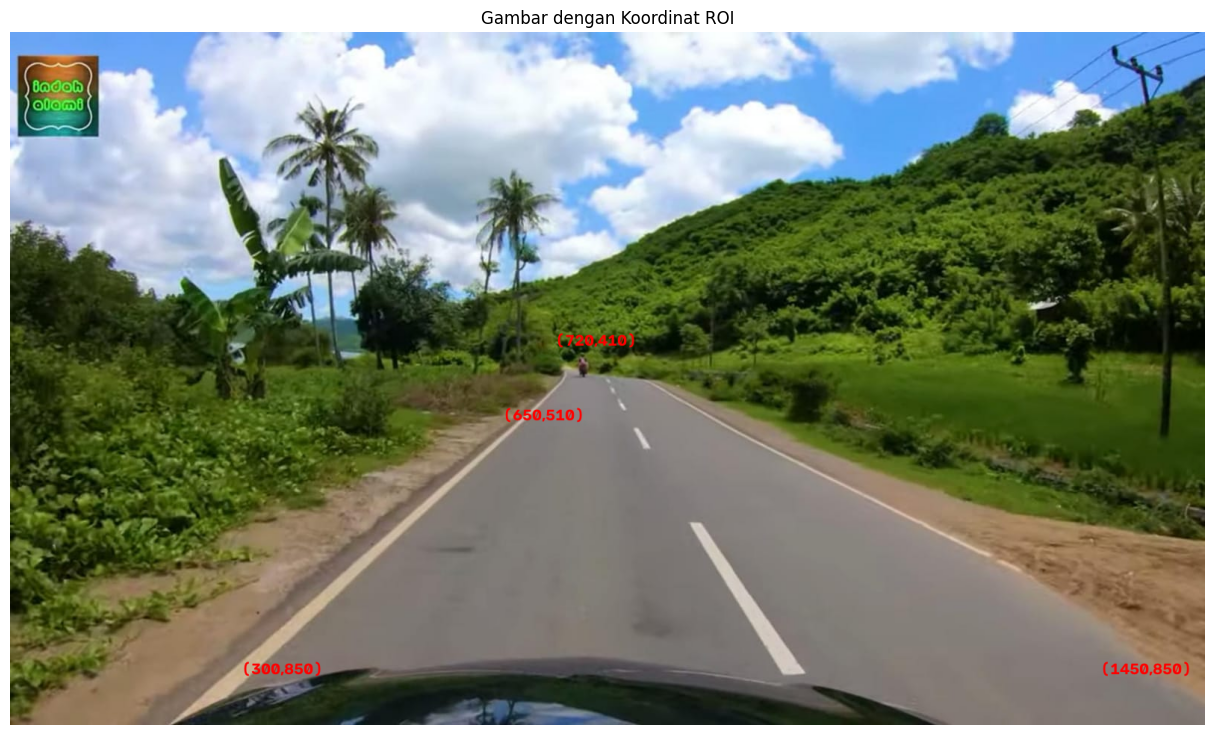

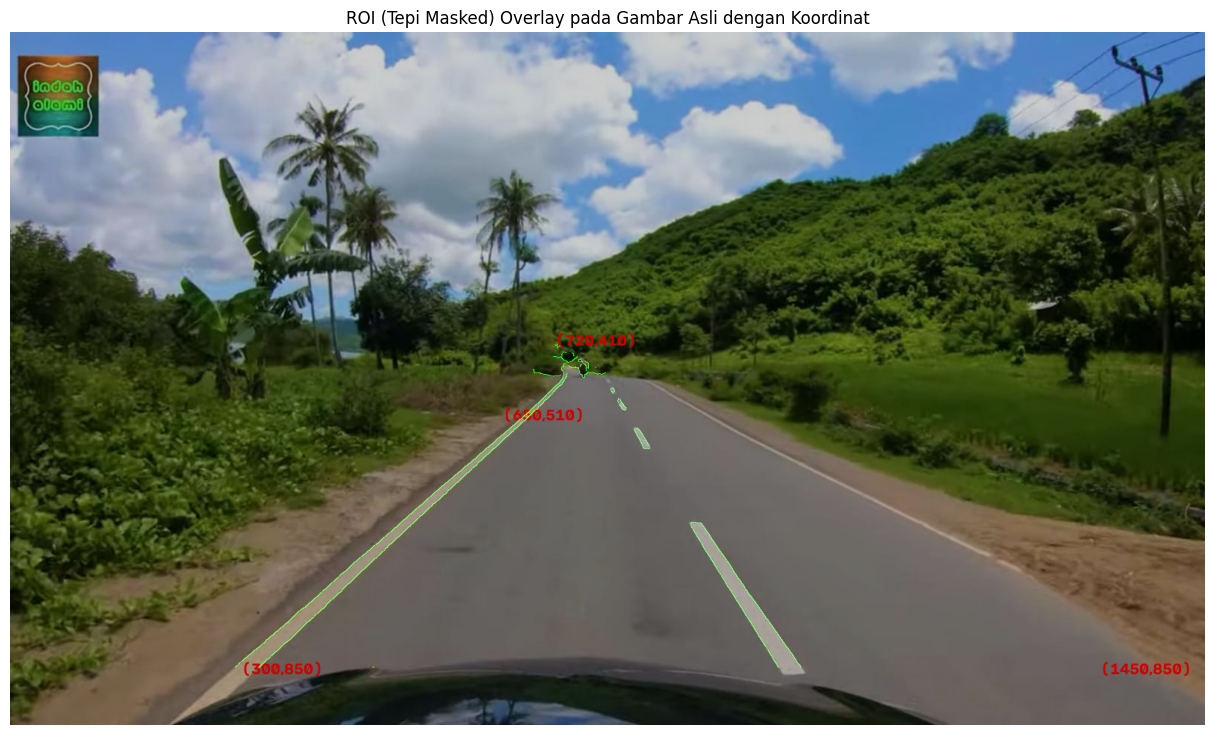

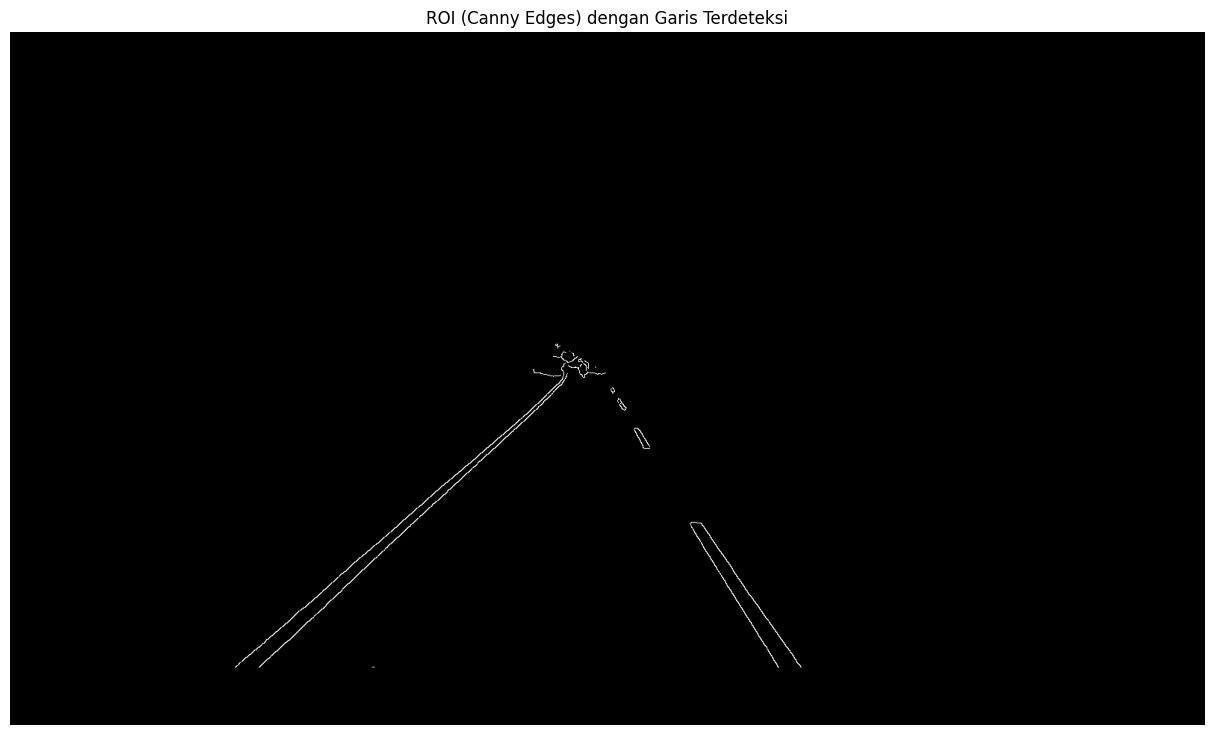

In [21]:
import numpy as np
import cv2 # ensure cv2 is available
import matplotlib.pyplot as plt # ensure matplotlib is available

# Recompute Canny edges for the static image to ensure consistent dimensions
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) # 'image' should be the original static image
blur = cv2.GaussianBlur(gray, (5, 5), 0)
edges_for_roi = cv2.Canny(blur, 50, 150) # Use a distinct variable name for clarity

# `height` and `width` are not strictly needed here as np.zeros_like(edges_for_roi) takes care of it
mask = np.zeros_like(edges_for_roi)

polygon = np.array([
    [
        (300, 850),    # kiri bawah
        (1450, 850),   # batas kanan bawah
        (720, 410),    # batas kanan atas
        (650, 510)     # batas kiri atas
    ]
], np.int32)

cv2.fillPoly(mask, polygon, 255)
roi = cv2.bitwise_and(edges_for_roi, mask) # Calculate roi from newly computed edges_for_roi

# Buat salinan gambar RGB untuk menggambar teks agar tidak memodifikasi gambar asli
image_with_coords = image_rgb.copy()

# Tambahkan angka koordinat pada gambar
for i, point in enumerate(polygon[0]):
    x, y = point
    # Menambahkan offset agar angka tidak menutupi titik
    cv2.putText(image_with_coords, f'({x},{y})', (x + 10, y + 10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2, cv2.LINE_AA)

# Plot 1: Gambar asli dengan koordinat ROI
plt.figure(figsize=(16, 9))
plt.imshow(image_with_coords)
plt.title("Gambar dengan Koordinat ROI")
plt.axis("off")
plt.show()

# Plot 2: Overlay ROI (tepian yang dimasker) pada gambar dengan koordinat
# Buat gambar 3-channel dari ROI untuk di-overlay
roi_colored = np.zeros_like(image_rgb)
roi_colored[roi > 0] = [0, 255, 0] # Now 'roi' has the correct (928, 1600) shape, compatible with image_rgb

# Gabungkan gambar asli dengan koordinat dan overlay ROI berwarna
image_with_roi_overlay = cv2.addWeighted(image_with_coords, 0.8, roi_colored, 1, 0)

plt.figure(figsize=(16, 9))
plt.imshow(image_with_roi_overlay)
plt.title("ROI (Tepi Masked) Overlay pada Gambar Asli dengan Koordinat")
plt.axis("off")
plt.show()

# Plot 3: ROI (Canny Edges) dengan Garis Terdeteksi
# Buat gambar 3-channel dari ROI untuk menggambar garis berwarna
roi_with_lines = cv2.cvtColor(roi, cv2.COLOR_GRAY2BGR)

if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(roi_with_lines, (x1, y1), (x2, y2), (0, 0, 255), 5) # Gambar garis biru

plt.figure(figsize=(16, 9))
plt.imshow(roi_with_lines)
plt.title("ROI (Canny Edges) dengan Garis Terdeteksi")
plt.axis("off")
plt.show()

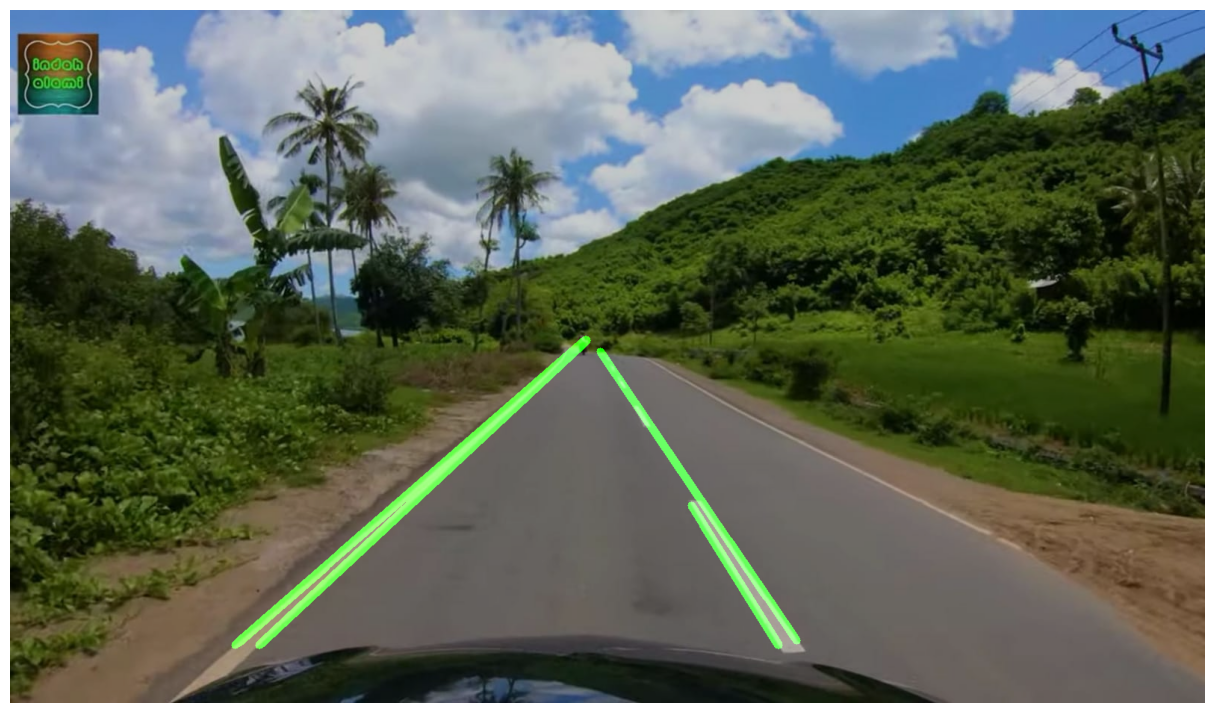

In [13]:
line_image = np.zeros_like(image)

if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line
        cv2.line(line_image, (x1, y1), (x2, y2), (0, 255, 0), 10)

result = cv2.addWeighted(
    image,
    0.8,
    line_image,
    1,
    0
)

result_rgb = cv2.cvtColor(
    result,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(16, 9))
plt.imshow(result_rgb)
plt.axis("off")
plt.show()

In [14]:
import cv2
import numpy as np
import time

VIDEO_PATH = "/content/drive/MyDrive/road-detection1/video_jalan.mp4"
OUTPUT_PATH = "/content/drive/MyDrive/road-detection1/output/video_jalan_lane_detection.mp4"

# Ukuran gambar asli (jalan.jpeg) tempat koordinat ROI ditentukan
ORIG_W, ORIG_H = 1600, 928

# Koordinat ROI
ROI_POLYGON_ORIG = np.array([
    (300, 850),    # kiri bawah
    (1450, 850),   # kanan bawah
    (720, 410),    # kanan atas
    (650, 510),    # kiri atas
], dtype=np.float32)

cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise RuntimeError("Video tidak dapat dibuka")

W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
FPS = cap.get(cv2.CAP_PROP_FPS)
TOTAL = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# Skala otomatis: ROI dari ukuran foto -> ukuran video
sx = W / ORIG_W
sy = H / ORIG_H
roi_scaled = ROI_POLYGON_ORIG.copy()
roi_scaled[:, 0] *= sx
roi_scaled[:, 1] *= sy
polygon = roi_scaled.astype(np.int32).reshape(1, -1, 2)

print(f"Video: {W}x{H} @ {FPS:.2f}fps, total frame: {TOTAL}")
print(f"ROI hasil scaling: {polygon.tolist()}")

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(OUTPUT_PATH, fourcc, FPS, (W, H))

t0 = time.time()
n = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blur, 50, 150)

    mask = np.zeros_like(edges)
    cv2.fillPoly(mask, polygon, 255)
    roi = cv2.bitwise_and(edges, mask)

    lines = cv2.HoughLinesP(
        roi, rho=1, theta=np.pi / 180, threshold=50,
        minLineLength=60, maxLineGap=100
    )

    line_image = np.zeros_like(frame)
    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line.ravel()
            cv2.line(line_image, (x1, y1), (x2, y2), (0, 255, 0), 8)

    result = cv2.addWeighted(frame, 0.8, line_image, 1, 0)
    out.write(result)

    n += 1
    if n % 2000 == 0:
        print(f"  {n}/{TOTAL} frame diproses ({time.time()-t0:.1f}s)")

cap.release()
out.release()
print(f"Selesai. {n} frame diproses dalam {time.time()-t0:.1f}s")
print(f"Video hasil tersimpan di: {OUTPUT_PATH}")

Video: 1280x720 @ 59.94fps, total frame: 25414
ROI hasil scaling: [[[240, 659], [1160, 659], [576, 318], [520, 395]]]
  2000/25414 frame diproses (42.7s)
  4000/25414 frame diproses (84.5s)
  6000/25414 frame diproses (128.0s)
  8000/25414 frame diproses (177.8s)
  10000/25414 frame diproses (222.3s)
  12000/25414 frame diproses (266.5s)
  14000/25414 frame diproses (313.9s)
  16000/25414 frame diproses (361.1s)
  18000/25414 frame diproses (404.4s)
  20000/25414 frame diproses (448.9s)
  22000/25414 frame diproses (494.6s)
  24000/25414 frame diproses (540.8s)
Selesai. 25409 frame diproses dalam 572.4s
Video hasil tersimpan di: /content/drive/MyDrive/road-detection1/output/video_jalan_lane_detection.mp4


In [15]:
from IPython.display import HTML
from base64 import b64encode

# Path video hasil proses Anda
OUTPUT_PATH = "/content/drive/MyDrive/road-detection1/output/video_jalan_lane_detection.mp4"

# Membaca dan mengkodekan video ke format base64
mp4 = open(OUTPUT_PATH, 'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

# Menampilkan pemutar video interaktif HTML5
HTML(f"""
<video width="800" controls>
      <source src="{data_url}" type="video/mp4">
</video>
""")

In [22]:
from IPython.display import HTML
from base64 import b64encode

# Gunakan path output yang benar sesuai dengan variabel sebelumnya
video_path = "/content/drive/MyDrive/road-detection1/output/video_jalan_lane_detection.mp4"

# Membaca dan mengkodekan video ke format base64
mp4 = open(video_path, 'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

# Menampilkan pemutar video interaktif HTML5
HTML(f"""
<video width="800" controls>
      <source src="{data_url}" type="video/mp4">
</video>
""")

In [ ]:
import os
import subprocess

RAW_OUTPUT = "/content/drive/MyDrive/road-detection1/output/video_jalan_lane_detection.mp4"
FIXED_OUTPUT = "/content/drive/MyDrive/road-detection1/output/video_jalan_lane_detection_fixed.mp4"

# 1) Pastikan folder output ada
os.makedirs(os.path.dirname(FIXED_OUTPUT), exist_ok=True)

# 2) Pastikan file input benar-benar ada sebelum di-convert
print("File input ada?", os.path.exists(RAW_OUTPUT))
print("Ukuran file:", os.path.getsize(RAW_OUTPUT) if os.path.exists(RAW_OUTPUT) else "N/A")

# 3) Jalankan ffmpeg dan tangkap error aslinya kalau gagal
result = subprocess.run(
    [
        "ffmpeg", "-y",
        "-i", RAW_OUTPUT,
        "-c:v", "libx264",
        "-preset", "veryfast",
        "-crf", "23",
        "-pix_fmt", "yuv420p",
        "-movflags", "+faststart",
        FIXED_OUTPUT
    ],
    capture_output=True, text=True
)

if result.returncode != 0:
    print("FFMPEG GAGAL:")
    print(result.stderr)
else:
    print("Berhasil! Video tersimpan di:", FIXED_OUTPUT)

File input ada? True
Ukuran file: 1170521598
